# Downloading Shards To Colab SSD

In [2]:
# ============================================================
# DOWNLOAD ALL SHARDS FROM GCS (for FUTURIST training)
# ============================================================

import os
from google.colab import auth
from google.cloud import storage
from tqdm import tqdm

BUCKET_NAME = "futurist_project_data"
SHARD_PREFIX = "seq-"      # We will match seq-00000.tar, seq-00123.tar, etc.
LOCAL_DIR = "/content/sequence_shards"

print("🔐 Authenticating...")
auth.authenticate_user()

# Setup GCS Client
client = storage.Client(project="explaindrive-ml")
bucket = client.bucket(BUCKET_NAME)

print(f"📁 Local directory: {LOCAL_DIR}")
os.makedirs(LOCAL_DIR, exist_ok=True)

print(f"📦 Listing objects in bucket: {BUCKET_NAME} ...")
all_blobs = list(bucket.list_blobs())

# Filter for seq-xxxxx.tar files
shard_blobs = [b for b in all_blobs if b.name.startswith("seq-") and b.name.endswith(".tar")]
shard_blobs = sorted(shard_blobs, key=lambda x: x.name)

print(f"🎯 Found {len(shard_blobs)} shard files in bucket.")
for b in shard_blobs[:5]:
    print("   🔹", b.name)

print("\n⬇️ Starting download of all shard files...\n")

for blob in tqdm(shard_blobs, desc="Downloading shards"):
    local_path = os.path.join(LOCAL_DIR, os.path.basename(blob.name))
    blob.download_to_filename(local_path)

print("\n🎉 ALL SHARDS DOWNLOADED SUCCESSFULLY!")
print(f"📁 Files saved in: {LOCAL_DIR}")


🔐 Authenticating...
📁 Local directory: /content/sequence_shards
📦 Listing objects in bucket: futurist_project_data ...
🎯 Found 169 shard files in bucket.
   🔹 seq-00000.tar
   🔹 seq-00001.tar
   🔹 seq-00002.tar
   🔹 seq-00003.tar
   🔹 seq-00004.tar

⬇️ Starting download of all shard files...




🎉 ALL SHARDS DOWNLOADED SUCCESSFULLY!
📁 Files saved in: /content/sequence_shards


# Defining Mini-Futurist

In [3]:
# ============================================================
# FIXED FUTURIST MODEL IMPLEMENTATION
# ============================================================

print("🧠 BUILDING FIXED FUTURIST MODEL ARCHITECTURE...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from einops import rearrange, repeat

# ============================================================
# MODEL CONFIGURATION (UPDATED)
# ============================================================

class FUTURISTConfig:
    # Image dimensions (from Cityscapes dataset)
    IMAGE_HEIGHT = 216  # Using your 288x512 resolution
    IMAGE_WIDTH = 384
    PATCH_SIZE = 12     # Fixed: Paper uses P=16

    # Derived values
    PATCHES_H = IMAGE_HEIGHT // PATCH_SIZE  # 18
    PATCHES_W = IMAGE_WIDTH // PATCH_SIZE   # 32
    NUM_PATCHES = PATCHES_H * PATCHES_W     # 576

    # Model dimensions (scaled down for memory optimization)
    HIDDEN_DIM = 192    # Reduced from 256 for memory
    NUM_LAYERS = 4      # Reduced from 6 for memory
    NUM_HEADS = 4
    MLP_RATIO = 4

    # Modality settings (FIXED according to paper)
    NUM_SEG_CLASSES = 19  # Cityscapes has 19 classes
    NUM_DEPTH_BINS = 50   # Paper uses discrete depth values
    PIXEL_EMBED_DIM = 10  # FIXED: Paper uses C_I=10 for pixel embeddings

    # Sequence settings (FIXED according to paper)
    NUM_CONTEXT = 4      # Paper: N_c=4 context frames
    NUM_FUTURE = 1       # Paper: N_p=1 future frame
    SEQ_LENGTH = NUM_CONTEXT + NUM_FUTURE  # 5

    # Training (we'll override masking to 100% on future)
    MASK_RATIO = 1.0   # Not used anymore for future frame, but kept for reference


config = FUTURISTConfig()

# ============================================================
# 1. HIERARCHICAL TOKENIZATION (FIXED)
# ============================================================

class HierarchicalTokenization(nn.Module):
    """VAE-free hierarchical tokenization - FIXED according to paper"""

    def __init__(self, modality_type, config):
        super().__init__()
        self.config = config
        self.modality_type = modality_type

        if modality_type == 'seg':
            num_values = config.NUM_SEG_CLASSES
        else:  # depth
            num_values = config.NUM_DEPTH_BINS

        # Stage 1: Per-pixel embedding (FIXED: paper uses low-dim embeddings)
        self.pixel_embed = nn.Embedding(num_values, config.PIXEL_EMBED_DIM)

        # Stage 2: Patch projection (FIXED: proper dimension calculation)
        patch_dim = config.PATCH_SIZE * config.PATCH_SIZE * config.PIXEL_EMBED_DIM
        # Each modality gets half the hidden dimension for Concat fusion
        self.patch_proj = nn.Linear(patch_dim, config.HIDDEN_DIM // 2)

    def forward(self, x):
        # x: [B, T, H, W] integer class indices
        batch_size, seq_len, H, W = x.shape

        # Stage 1: Per-pixel embedding
        x_embed = self.pixel_embed(x)  # [B, T, H, W, embed_dim]

        # Reshape for patching: [B, T, H, W, embed_dim] -> [B, T, num_patches, patch_size² * embed_dim]
        x_embed = rearrange(
            x_embed,
            'b t (h p1) (w p2) d -> b t (h w) (p1 p2 d)',
            p1=self.config.PATCH_SIZE,
            p2=self.config.PATCH_SIZE,
            h=self.config.PATCHES_H,
            w=self.config.PATCHES_W
        )

        # Stage 2: Patch projection
        tokens = self.patch_proj(x_embed)  # [B, T, num_patches, hidden_dim//2]

        return tokens

# ============================================================
# 2. MULTIMODAL FUSION (FIXED)
# ============================================================

class MultimodalFusion(nn.Module):
    """Early fusion via concatenation - FIXED: paper uses Concat strategy"""

    def __init__(self, config):
        super().__init__()
        self.config = config

    def forward(self, seg_tokens, depth_tokens):
        # Concat along feature dimension: [B, T, N, D/2] + [B, T, N, D/2] -> [B, T, N, D]
        # This matches paper's Concat strategy where d_S = d_D = d/2
        fused_tokens = torch.cat([seg_tokens, depth_tokens], dim=-1)
        return fused_tokens

# ============================================================
# 3. DECOMPOSED ATTENTION (FIXED)
# ============================================================

class DecomposedAttention(nn.Module):
    """Spatio-temporal decomposed attention (correct Pre-LN)"""

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.head_dim = config.HIDDEN_DIM // config.NUM_HEADS

        # QKV and output projections
        self.qkv = nn.Linear(config.HIDDEN_DIM, 3 * config.HIDDEN_DIM)
        self.proj = nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM)

        # REQUIRED Pre-LN (must not be removed)
        self.norm = nn.LayerNorm(config.HIDDEN_DIM)

    def forward(self, x, attention_type='spatial'):
        B, T, N, D = x.shape

        # ---------- PRE-LAYER NORM ----------
        x = self.norm(x)

        # ---------- RESHAPE FOR ATTENTION ----------
        if attention_type == 'spatial':
            # [B, T, N, D] → [B*T, N, D]
            x_flat = x.reshape(B * T, N, D)
            seq_len = N
        else:
            # [B, T, N, D] → [B*N, T, D]
            x_flat = x.permute(0, 2, 1, 3).reshape(B * N, T, D)
            seq_len = T

        # ---------- COMPUTE QKV ----------
        qkv = self.qkv(x_flat).reshape(
            x_flat.shape[0], seq_len, 3, self.config.NUM_HEADS, self.head_dim
        )
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # ---------- ATTENTION ----------
        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))
        attn = F.softmax(attn, dim=-1)

        # ---------- OUTPUT ----------
        out = (attn @ v).transpose(1, 2).reshape(x_flat.shape[0], seq_len, D)
        out = self.proj(out)

        # ---------- RESHAPE BACK ----------
        if attention_type == 'spatial':
            out = out.reshape(B, T, N, D)
        else:
            out = out.reshape(B, N, T, D).permute(0, 2, 1, 3)

        return out

# ============================================================
# 4. TRANSFORMER BLOCK (FIXED)
# ============================================================

class TransformerBlock(nn.Module):
    """Pre-LN transformer block with decomposed attention - FIXED"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # Decomposed attention layers
        self.temporal_attention = DecomposedAttention(config)
        self.spatial_attention = DecomposedAttention(config)

        # Pre-LN normalization
        self.norm1 = nn.LayerNorm(config.HIDDEN_DIM)
        self.norm2 = nn.LayerNorm(config.HIDDEN_DIM)
        self.norm3 = nn.LayerNorm(config.HIDDEN_DIM)

        # MLP (FIXED: paper uses MLP with ratio)
        mlp_dim = config.HIDDEN_DIM * config.MLP_RATIO
        self.mlp = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, config.HIDDEN_DIM)
        )

    def forward(self, x):
        # x: [B, T, N, D]

        # Temporal attention (across frames at same spatial position)
        residual = x
        x_temp = self.temporal_attention(self.norm1(x), 'temporal')
        x = residual + x_temp

        # Spatial attention (within same frame)
        residual = x
        x_spatial = self.spatial_attention(self.norm2(x), 'spatial')
        x = residual + x_spatial

        # MLP
        residual = x
        x = self.mlp(self.norm3(x))
        x = residual + x

        return x

# ============================================================
# 5. SPATIO-TEMPORAL TRANSFORMER (FIXED - DIMENSION ISSUE RESOLVED)
# ============================================================

class SpatioTemporalTransformer(nn.Module):
    """Main transformer backbone - FIXED position embeddings"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # Position embeddings (FIXED: match exact dimensions)
        self.temp_pos_embed = nn.Parameter(
            torch.randn(1, config.SEQ_LENGTH, 1, config.HIDDEN_DIM) * 0.02
        )
        self.spatial_pos_embed = nn.Parameter(
            torch.randn(1, 1, config.NUM_PATCHES, config.HIDDEN_DIM) * 0.02
        )

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config.NUM_LAYERS)
        ])
        self.norm = nn.LayerNorm(config.HIDDEN_DIM)

    def forward(self, x):
        B, T, N, D = x.shape

        # Add position embeddings (FIXED: ensure dimensions match exactly)
        x = x + self.temp_pos_embed[:, :T, :, :]      # Temporal: [1, T, 1, D]
        x = x + self.spatial_pos_embed[:, :, :N, :]   # Spatial: [1, 1, N, D]

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        return self.norm(x)

# ============================================================
# 6. MULTIMODAL MASKING (UPDATED: FUTURE FRAME 100% MASKED)
# ============================================================

class MultimodalMasking(nn.Module):
    """
    FUTURIST-style masking:
    - Context frames (0..NUM_CONTEXT-1) are NEVER masked
    - Future frames (last NUM_FUTURE) are ALWAYS 100% masked during training
    - No masking during inference
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.mask_token_seg = nn.Parameter(torch.randn(1, 1, 1, config.HIDDEN_DIM // 2))
        self.mask_token_depth = nn.Parameter(torch.randn(1, 1, 1, config.HIDDEN_DIM // 2))

    def forward(self, seg_tokens, depth_tokens):
      """
      seg_tokens, depth_tokens: [B, T, N, D/2]

      TRAINING:
          - Context frames (0..NUM_CONTEXT-1): unchanged
          - Future frame(s) (last NUM_FUTURE): 100% masked for BOTH seg + depth
          - seg_mask / depth_mask: True for ALL tokens in future frame(s)

      INFERENCE:
          - No masking at all
          - seg_mask / depth_mask = None
      """
      B, T, N, D = seg_tokens.shape
      F = self.config.NUM_FUTURE  # 1

      # Split context and future
      context_seg   = seg_tokens[:, :self.config.NUM_CONTEXT]      # [B, 4, N, D/2]
      context_depth = depth_tokens[:, :self.config.NUM_CONTEXT]

      future_seg   = seg_tokens[:, self.config.NUM_CONTEXT:]       # [B, 1, N, D/2]
      future_depth = depth_tokens[:, self.config.NUM_CONTEXT:]

      # INFERENCE: no masking at all
      if not self.training:
          seg_tokens_masked   = torch.cat([context_seg, future_seg], dim=1)
          depth_tokens_masked = torch.cat([context_depth, future_depth], dim=1)
          seg_mask = None
          depth_mask = None
          return seg_tokens_masked, depth_tokens_masked, seg_mask, depth_mask

      # TRAINING: 100% mask the future frame(s) for BOTH modalities
      masked_seg   = future_seg.clone()
      masked_depth = future_depth.clone()

      # Broadcast mask tokens: [1,1,1,D/2] -> [B,F,N,D/2]
      masked_seg[:]   = self.mask_token_seg
      masked_depth[:] = self.mask_token_depth

      # All tokens in future frame(s) are supervised
      seg_mask   = torch.ones(B, F, N, device=seg_tokens.device, dtype=torch.bool)
      depth_mask = torch.ones(B, F, N, device=seg_tokens.device, dtype=torch.bool)

      # Reconstruct full sequence
      seg_tokens_masked   = torch.cat([context_seg, masked_seg], dim=1)      # [B,5,N,D/2]
      depth_tokens_masked = torch.cat([context_depth, masked_depth], dim=1)  # [B,5,N,D/2]

      return seg_tokens_masked, depth_tokens_masked, seg_mask, depth_mask

# ============================================================
# 7. MULTIMODAL DECODER (FIXED - Weight Tying)
# ============================================================

class MultimodalDecoder(nn.Module):
    """Decoder with weight tying - FIXED according to paper"""

    def __init__(self, seg_embedder, depth_embedder, config):
        super().__init__()
        self.config = config
        self.seg_embedder = seg_embedder
        self.depth_embedder = depth_embedder

        # Project back to patch space (FIXED: mirror of embedder)
        patch_dim = config.PATCH_SIZE * config.PATCH_SIZE * config.PIXEL_EMBED_DIM
        self.seg_proj = nn.Linear(config.HIDDEN_DIM, patch_dim)
        self.depth_proj = nn.Linear(config.HIDDEN_DIM, patch_dim)

    def forward(self, x):
        # Extract only future frames for prediction
        future_tokens = x[:, -self.config.NUM_FUTURE:]  # [B, F, N, D]
        B, F, N, D = future_tokens.shape

        # Project back to patch space
        seg_patch = self.seg_proj(future_tokens)   # [B, F, N, P*P*C]
        depth_patch = self.depth_proj(future_tokens)

        # Reshape to pixel-level and use tied weights (FIXED: paper uses weight tying)
        seg_recon = self._decode_modality(seg_patch, self.seg_embedder.pixel_embed.weight)
        depth_recon = self._decode_modality(depth_patch, self.depth_embedder.pixel_embed.weight)

        return seg_recon, depth_recon

    def _decode_modality(self, patches, embedding_weight):
        B, F, N, patch_dim = patches.shape

        # Reshape to image format: [B, F, N, P*P*C] -> [B, F, H, W, C]
        patches = patches.view(
            B, F, N,
            self.config.PATCH_SIZE, self.config.PATCH_SIZE,
            self.config.PIXEL_EMBED_DIM
        )
        patches = rearrange(
            patches,
            'b f (h w) p1 p2 d -> b f (h p1) (w p2) d',
            h=self.config.PATCHES_H,
            w=self.config.PATCHES_W,
            p1=self.config.PATCH_SIZE,
            p2=self.config.PATCH_SIZE
        )

        # Final projection with weight tying
        # embedding_weight: [num_classes, embed_dim], patches: [B, F, H, W, embed_dim]
        logits = torch.einsum('bfhwd,cd->bfhwc', patches, embedding_weight)  # [B, F, H, W, C]
        logits = logits.permute(0, 1, 4, 2, 3)  # [B, F, C, H, W]

        return logits

# ============================================================
# 8. COMPLETE FIXED FUTURIST MODEL
# ============================================================

class FixedFUTURIST(nn.Module):
    """Complete FUTURIST model with all fixes according to paper"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # 1. Tokenization (VAE-free) - FIXED
        self.seg_embedder = HierarchicalTokenization('seg', config)
        self.depth_embedder = HierarchicalTokenization('depth', config)

        # 2. Multimodal fusion - FIXED: Concat strategy
        self.fusion = MultimodalFusion(config)

        # 3. Masking strategy - FUTURIST-style (future fully masked)
        self.masking = MultimodalMasking(config)

        # 4. Transformer backbone - Spatio-temporal with decomposed attention
        self.transformer = SpatioTemporalTransformer(config)

        # 5. Decoder - Weight tying
        self.decoder = MultimodalDecoder(self.seg_embedder, self.depth_embedder, config)

        print(f"✅ FIXED FUTURIST Model Created:")
        print(f"   - Parameters: {sum(p.numel() for p in self.parameters()):,}")
        print(f"   - Hidden dim: {config.HIDDEN_DIM}")
        print(f"   - Layers: {config.NUM_LAYERS}")
        print(f"   - Sequence: {config.SEQ_LENGTH} frames ({config.NUM_CONTEXT} context + {config.NUM_FUTURE} future)")
        print(f"   - Image: {config.IMAGE_HEIGHT}x{config.IMAGE_WIDTH} -> {config.NUM_PATCHES} patches")
        print(f"   - Pixel embed dim: {config.PIXEL_EMBED_DIM} (paper: 10)")
        print(f"   - Masking: Future frame 100% masked during training")

    def forward(self, seg_seq, depth_seq, apply_masking=True):
      """
      TRAINING:
          seg_seq, depth_seq: [B, 5, H, W]
          - 4 context frames visible
          - 5th future frame fully masked inside MultimodalMasking

      INFERENCE:
          seg_seq, depth_seq: [B, 4, H, W]
          - we auto-create a dummy 5th frame (all zeros)
          - masking is disabled automatically
      """
      B, T, H, W = seg_seq.shape
      device = seg_seq.device

      # ------------------------------------------------------------
      # 1. INFERENCE CASE: If only 4 frames given, append dummy frame
      # ------------------------------------------------------------
      if T == self.config.NUM_CONTEXT:  # T == 4
          masked_seg_frame = torch.zeros((B, 1, H, W), dtype=torch.long, device=device)
          masked_depth_frame = torch.zeros((B, 1, H, W), dtype=torch.long, device=device)

          # Now sequence becomes [B, 5, H, W]
          seg_seq = torch.cat([seg_seq, masked_seg_frame], dim=1)
          depth_seq = torch.cat([depth_seq, masked_depth_frame], dim=1)

          # DO NOT apply training-time masking at inference
          apply_masking = False

      # Safety check
      assert seg_seq.shape[1] == self.config.SEQ_LENGTH, \
          f"Expected {self.config.SEQ_LENGTH} frames, got {seg_seq.shape[1]}"

      # ------------------------------------------------------------
      # 2. Tokenize inputs
      # ------------------------------------------------------------
      seg_tokens = self.seg_embedder(seg_seq)      # [B, 5, N, D/2]
      depth_tokens = self.depth_embedder(depth_seq)

      # ------------------------------------------------------------
      # 3. Apply FUTURIST masking (training only)
      # ------------------------------------------------------------
      seg_mask = depth_mask = None
      if apply_masking and self.training:
          seg_tokens, depth_tokens, seg_mask, depth_mask = self.masking(
              seg_tokens, depth_tokens
          )

      # ------------------------------------------------------------
      # 4. Multimodal fusion
      # ------------------------------------------------------------
      fused_tokens = self.fusion(seg_tokens, depth_tokens)        # [B, 5, N, D]

      # ------------------------------------------------------------
      # 5. Spatio-temporal Transformer encoder
      # ------------------------------------------------------------
      encoded_tokens = self.transformer(fused_tokens)             # [B, 5, N, D]

      # ------------------------------------------------------------
      # 6. Decode prediction ONLY for future frame (1 frame)
      # ------------------------------------------------------------
      seg_pred, depth_pred = self.decoder(encoded_tokens)         # [B, 1, C, H, W]

      return seg_pred, depth_pred, seg_mask, depth_mask

    def predict_future(self, seg_4, depth_4):
        """
        Convenience method for inference:
        seg_4, depth_4: [B, 4, H, W]
        Returns:
            seg_logits:   [B, C_seg, H, W]
            depth_logits: [B, C_depth, H, W]
        """
        self.eval()
        with torch.no_grad():
            seg_pred, depth_pred, _, _ = self.forward(
                seg_4, depth_4, apply_masking=False
            )
        # seg_pred, depth_pred: [B, 1, C, H, W]
        return seg_pred[:, 0], depth_pred[:, 0]

# ============================================================
# 9. LOSS FUNCTION (FIXED - Masked Cross-Entropy)
# ============================================================

class FixedFUTURISTLoss(nn.Module):
    """Masked multimodal loss function"""

    def __init__(self, config):
        super().__init__()
        self.config = config

    def forward(self, seg_pred, depth_pred, seg_target, depth_target,
                seg_mask=None, depth_mask=None):
        """
        seg_pred, depth_pred: [B, F, C, H, W]  (F = NUM_FUTURE = 1)
        seg_target, depth_target: [B, T, H, W] (T = 5)
        seg_mask, depth_mask: [B, F, N] where N = NUM_PATCHES
        """
        batch_size, num_future, C_seg, H, W = seg_pred.shape
        _, _, C_depth, _, _ = depth_pred.shape

        # ---- 1) Extract only future targets ----
        seg_target_future = seg_target[:, -self.config.NUM_FUTURE:]      # [B, F, H, W]
        depth_target_future = depth_target[:, -self.config.NUM_FUTURE:]  # [B, F, H, W]

        # ---- 2) Flatten predictions & targets ----
        # [B, F, C, H, W] -> [B*F*H*W, C]
        seg_pred_flat = seg_pred.permute(0, 1, 3, 4, 2).reshape(
            batch_size * num_future * H * W, C_seg
        )
        seg_target_flat = seg_target_future.reshape(batch_size * num_future * H * W)

        depth_pred_flat = depth_pred.permute(0, 1, 3, 4, 2).reshape(
            batch_size * num_future * H * W, C_depth
        )
        depth_target_flat = depth_target_future.reshape(batch_size * num_future * H * W)

        # ---- 3) Optional masked loss (token-wise) ----
        if seg_mask is not None and depth_mask is not None:
            # seg_mask, depth_mask: [B, F, N]
            # Flatten to [B*F*N]
            seg_mask_flat = seg_mask.reshape(batch_size * num_future * self.config.NUM_PATCHES)
            depth_mask_flat = depth_mask.reshape(batch_size * num_future * self.config.NUM_PATCHES)

            # Each token corresponds to PATCH_SIZE^2 pixels.
            # Expand mask from tokens -> pixels.
            seg_mask_pixels = repeat(
                seg_mask_flat, 'n -> (n p1 p2)',
                p1=self.config.PATCH_SIZE, p2=self.config.PATCH_SIZE
            )
            depth_mask_pixels = repeat(
                depth_mask_flat, 'n -> (n p1 p2)',
                p1=self.config.PATCH_SIZE, p2=self.config.PATCH_SIZE
            )

            # seg_mask_pixels, depth_mask_pixels: [B*F*H*W] boolean
            seg_loss = F.cross_entropy(
                seg_pred_flat[seg_mask_pixels],
                seg_target_flat[seg_mask_pixels]
            )
            depth_loss = F.cross_entropy(
                depth_pred_flat[depth_mask_pixels],
                depth_target_flat[depth_mask_pixels]
            )
        else:
            # Fallback: loss on all pixels of future frame
            seg_loss = F.cross_entropy(seg_pred_flat, seg_target_flat)
            depth_loss = F.cross_entropy(depth_pred_flat, depth_target_flat)

        total_loss = seg_loss + depth_loss
        return total_loss, seg_loss, depth_loss

# ============================================================
# MEMORY OPTIMIZATION SETTINGS
# ============================================================

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("🔧 Memory optimization settings applied:")
print("   - Reduced HIDDEN_DIM: 256 → 192")
print("   - Reduced NUM_LAYERS: 6 → 4")
print("   - PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True")
print("   - Ready for gradient accumulation training")


🧠 BUILDING FIXED FUTURIST MODEL ARCHITECTURE...
🔧 Memory optimization settings applied:
   - Reduced HIDDEN_DIM: 256 → 192
   - Reduced NUM_LAYERS: 6 → 4
   - PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True
   - Ready for gradient accumulation training


# Dataloader

In [4]:
# ============================================================
# FINAL OPTIMIZED DATA LOADER FOR FUTURIST TRAINING (.NPY VERSION)
# ============================================================

print("🎯 BUILDING FINAL OPTIMIZED DATA LOADER (.NPY VERSION)...")
!pip install webdataset
import webdataset as wds
from torch.utils.data import DataLoader
import torch
import numpy as np

# ============================================================
# CONFIGURATION - FIXED TO MATCH MODEL
# ============================================================

config.NUM_DEPTH_BINS = 50
TARGET_SIZE = (384, 216)  # (width, height) - MUST match model's IMAGE_WIDTH x IMAGE_HEIGHT
BATCH_SIZE = 8
NUM_WORKERS = 1

# ============================================================
# SIMPLIFIED PREPROCESSING FUNCTIONS - NO RESIZING NEEDED
# ============================================================

def preprocess_segmentation_npy(npy_data):
    """Convert segmentation .npy array directly to tensor - ALREADY RESIZED"""
    try:
        # npy_data is already [H, W] with values 0-19 and correct size
        seg_array = np.array(npy_data)

        # Simply convert to tensor and add channel dimension
        seg_tensor = torch.from_numpy(seg_array).long().unsqueeze(0)  # [1, H, W]

        return seg_tensor

    except Exception as e:
        print(f"Error in preprocess_segmentation_npy: {e}")
        return None

def preprocess_depth_npy(npy_data, num_bins=50):
    """Convert depth .npy array directly to tensor - ALREADY RESIZED"""
    try:
        # npy_data is already [H, W] with values 0-49 and correct size
        depth_array = np.array(npy_data)

        # Simply convert to tensor and add channel dimension
        depth_tensor = torch.from_numpy(depth_array).long().unsqueeze(0)  # [1, H, W]

        return depth_tensor

    except Exception as e:
        print(f"Error in preprocess_depth_npy: {e}")
        return None

# ============================================================
# CUSTOM DECODER FOR .NPY FILES
# ============================================================

def decode_npy(key, data):
    """Custom decoder for .npy files"""
    if key.endswith('.npy'):
        import io
        return np.load(io.BytesIO(data))
    return data

# ============================================================
# FINAL DATA LOADER - SIMPLIFIED FOR PRE-RESIZED .NPY FILES
# ============================================================

def create_final_futurist_loader_npy(shard_pattern, batch_size=8, num_workers=2):
    """Final optimized WebDataset pipeline for pre-processed .npy files"""

    def process_sample(sample):
        try:
            seg_frames = []
            depth_frames = []

            for i in range(5):  # frames 00-04
                # CORRECT: WebDataset strips key prefixes
                seg_key = f'label{i:02d}.npy'
                depth_key = f'depth{i:02d}.npy'

                # DIRECT CONVERSION - no resizing needed
                seg_tensor = preprocess_segmentation_npy(sample[seg_key])
                depth_tensor = preprocess_depth_npy(sample[depth_key], num_bins=config.NUM_DEPTH_BINS)

                if seg_tensor is None or depth_tensor is None:
                    return None

                seg_frames.append(seg_tensor)
                depth_frames.append(depth_tensor)

            # Stack into sequences [5, 1, H, W]
            seg_sequence = torch.stack(seg_frames)      # [5, 1, 216, 384]
            depth_sequence = torch.stack(depth_frames)  # [5, 1, 216, 384]

            # FUTURIST: Use frames 0-3 as context, frame 4 as future target
            return {
                'seg_sequence': seg_sequence,        # [5, 1, 216, 384] - 0-19 class indices
                'depth_sequence': depth_sequence,    # [5, 1, 216, 384] - 0-49 depth bins
                'seg_target': seg_sequence[4:5],     # [1, 1, 216, 384] - frame 4 target
                'depth_target': depth_sequence[4:5], # [1, 1, 216, 384] - frame 4 target
            }

        except Exception as e:
            print(f"Sample processing error: {e}")
            return None

    # Optimized WebDataset pipeline with custom .npy decoder
    dataset = (wds.WebDataset(shard_pattern, shardshuffle=100)
              .decode(decode_npy)  # Custom decoder for .npy files
              .map(process_sample)
              .select(lambda x: x is not None)
              .batched(batch_size, partial=False))

    return DataLoader(dataset, batch_size=None, num_workers=num_workers,
                     pin_memory=True, persistent_workers=True)

# ============================================================
# CREATE AND TEST FINAL DATA LOADER (.NPY VERSION)
# ============================================================

print("🔄 Creating final optimized data loader (.npy version)...")
shard_pattern = "/content/sequence_shards/seq-{00000..00168}.tar"

train_loader = create_final_futurist_loader_npy(
    shard_pattern=shard_pattern,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

print("✅ FINAL DATA LOADER CREATED (.NPY VERSION)!")
print(f"   📊 Dataset Summary:")
print(f"      • 2168 shards × 250 samples = x sequences")
print(f"      • Batch size: {BATCH_SIZE}")
print(f"      • Workers: {NUM_WORKERS}")
print(f"      • Target resolution: {TARGET_SIZE[0]}×{TARGET_SIZE[1]} (PRE-RESIZED)")
print(f"      • Segmentation: 20 classes (0-19) - PRE-NORMALIZED")
print(f"      • Depth: 50 discrete bins (0-49) - PRE-NORMALIZED")
print(f"      • Format: .npy arrays (pre-processed)")

# Test the loader
print(f"\n🧪 Testing final data loader (.npy version)...")
try:
    for i, batch in enumerate(train_loader):
        if batch is not None:
            print(f"🎉 Batch {i} SUCCESS!")
            print(f"   seg_sequence: {batch['seg_sequence'].shape}")
            print(f"   depth_sequence: {batch['depth_sequence'].shape}")
            print(f"   seg_target: {batch['seg_target'].shape}")
            print(f"   depth_target: {batch['depth_target'].shape}")

            # Check value ranges
            seg_min, seg_max = batch['seg_sequence'].min().item(), batch['seg_sequence'].max().item()
            depth_min, depth_max = batch['depth_sequence'].min().item(), batch['depth_sequence'].max().item()

            print(f"   ✅ Segmentation range: {seg_min}-{seg_max} (0-19 expected)")
            print(f"   ✅ Depth bins range: {depth_min}-{depth_max} (0-49 expected)")

            # Verify tensor shapes
            seg_shape = batch['seg_sequence'].shape
            depth_shape = batch['depth_sequence'].shape
            print(f"   ✅ Sequence shape: {seg_shape} (5 frames, 1 channel, {TARGET_SIZE[1]}H, {TARGET_SIZE[0]}W)")
            print(f"   ✅ Batch dimensions correct for FUTURIST model!")

            if i >= 1:  # Test 2 batches
                break

except Exception as e:
    print(f"❌ Test failed: {e}")
    import traceback
    traceback.print_exc()

print(f"\n🚀 FINAL DATA LOADER READY FOR TRAINING!")
print(f"   🎯 Training task: Predict frame 4 from frames 0-3")
print(f"   💡 All preprocessing done offline - fast loading!")

🎯 BUILDING FINAL OPTIMIZED DATA LOADER (.NPY VERSION)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.4 MB/s eta 0:00:00
🔄 Creating final optimized data loader (.npy version)...
✅ FINAL DATA LOADER CREATED (.NPY VERSION)!
   📊 Dataset Summary:
      • 2168 shards × 250 samples = x sequences
      • Batch size: 8
      • Workers: 1
      • Target resolution: 384×216 (PRE-RESIZED)
      • Segmentation: 20 classes (0-19) - PRE-NORMALIZED
      • Depth: 50 discrete bins (0-49) - PRE-NORMALIZED
      • Format: .npy arrays (pre-processed)

🧪 Testing final data loader (.npy version)...
🎉 Batch 0 SUCCESS!
   seg_sequence: torch.Size([8, 5, 1, 216, 384])
   depth_sequence: torch.Size([8, 5, 1, 216, 384])
   seg_target: torch.Size([8, 1, 1, 216, 384])
   depth_target: torch.Size([8, 1, 1, 216, 384])
   ✅ Segmentation range: 0-18 (0-19 expected)
   ✅ Depth bins range: 0-49 (0-49 expected)
   ✅ Sequence shape: torch.Size([8, 5, 1, 216, 384]) (5 frames, 1 channel, 216H, 384W)
   ✅ Bat

# Train and Evaluation

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def sanity_check(model, loader, config):
    print("🔍 Running FUTURIST sanity check...")

    device = next(model.parameters()).device

    # Get ONE batch
    batch = next(iter(loader))

    seg_seq = batch['seg_sequence'].to(device)[:, :, 0]      # [B,5,H,W]
    depth_seq = batch['depth_sequence'].to(device)[:, :, 0]
    seg_target = batch['seg_target'].to(device)[:, :, 0]
    depth_target = batch['depth_target'].to(device)[:, :, 0]

    print(f"🟦 seg_seq shape: {seg_seq.shape}")
    print(f"🟧 depth_seq shape: {depth_seq.shape}")
    print(f"🟩 seg_target shape: {seg_target.shape}")
    print(f"🟨 depth_target shape: {depth_target.shape}")

    B, T, H, W = seg_seq.shape

    # --------------------------------------------------------------
    # 1) Verify there are 5 frames and correct values
    # --------------------------------------------------------------
    assert T == 5, f"Expected 5 frames, got {T}"
    assert seg_seq.max() < config.NUM_SEG_CLASSES
    assert depth_seq.max() < config.NUM_DEPTH_BINS

    print("✔️ Frame count & value ranges OK")

    # --------------------------------------------------------------
    # 2) Switch model to eval to disable masking
    # --------------------------------------------------------------
    model.eval()
    with torch.no_grad():
        seg_pred, depth_pred, _, _ = model(seg_seq, depth_seq, apply_masking=False)

    print(f"🟣 seg_pred shape: {seg_pred.shape}")
    print(f"🟡 depth_pred shape: {depth_pred.shape}")

    # --------------------------------------------------------------
    # 3) No NaNs allowed
    # --------------------------------------------------------------
    assert torch.isfinite(seg_pred).all(), "❌ seg_pred contains NaN/inf"
    assert torch.isfinite(depth_pred).all(), "❌ depth_pred contains NaN/inf"

    print("✔️ No NaNs or inf in predictions")

    # --------------------------------------------------------------
    # 4) Predictions should be logits (not softmaxed) but not all zeros
    # --------------------------------------------------------------
    print("seg_pred stats:", seg_pred.min().item(), seg_pred.max().item())
    print("depth_pred stats:", depth_pred.min().item(), depth_pred.max().item())

    assert seg_pred.max() - seg_pred.min() > 1e-4, "❌ seg_pred is degenerate (all same value)"
    assert depth_pred.max() - depth_pred.min() > 1e-4, "❌ depth_pred is degenerate (all same value)"

    print("✔️ Logits look sane (non-degenerate)")

    # --------------------------------------------------------------
    # 5) Visualize first example: GT vs Prediction for segmentation
    # --------------------------------------------------------------
    seg_pred_labels = torch.argmax(seg_pred, dim=2)[0, 0].cpu().numpy()
    seg_gt = seg_target[0, -1].cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Predicted Future Seg")
    plt.imshow(seg_pred_labels, cmap="nipy_spectral")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("GT Future Seg")
    plt.imshow(seg_gt, cmap="nipy_spectral")
    plt.axis('off')

    plt.show()

    # --------------------------------------------------------------
    # 6) Depth – visualize disparity bin maps
    # --------------------------------------------------------------
    depth_pred_bins = torch.argmax(depth_pred, dim=2)[0, 0].cpu().numpy()
    depth_gt = depth_target[0, -1].cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Predicted Future Depth")
    plt.imshow(depth_pred_bins, cmap="inferno")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("GT Future Depth")
    plt.imshow(depth_gt, cmap="inferno")
    plt.axis('off')

    plt.show()

    print("🎉 SANITY CHECK COMPLETE — MODEL BEHAVING NORMALLY")


✅ FIXED FUTURIST Model Created:
   - Parameters: 3,322,290
   - Hidden dim: 192
   - Layers: 4
   - Sequence: 5 frames (4 context + 1 future)
   - Image: 216x384 -> 576 patches
   - Pixel embed dim: 10 (paper: 10)
   - Masking: Future frame 100% masked during training
🔍 Running FUTURIST sanity check...
🟦 seg_seq shape: torch.Size([4, 5, 216, 384])
🟧 depth_seq shape: torch.Size([4, 5, 216, 384])
🟩 seg_target shape: torch.Size([4, 1, 216, 384])
🟨 depth_target shape: torch.Size([4, 1, 216, 384])
✔️ Frame count & value ranges OK
🟣 seg_pred shape: torch.Size([4, 1, 19, 216, 384])
🟡 depth_pred shape: torch.Size([4, 1, 50, 216, 384])
✔️ No NaNs or inf in predictions
seg_pred stats: -8.991811752319336 10.062850952148438
depth_pred stats: -12.360172271728516 12.230194091796875
✔️ Logits look sane (non-degenerate)


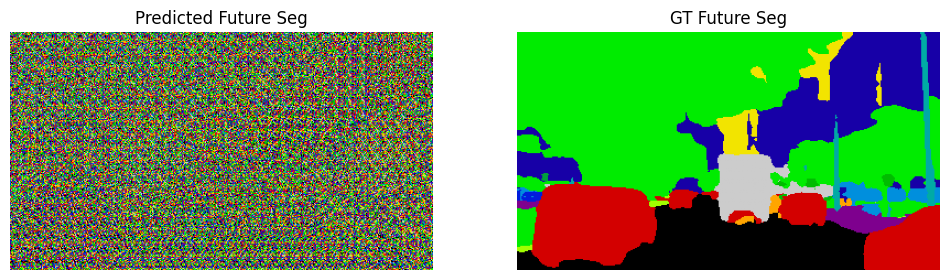

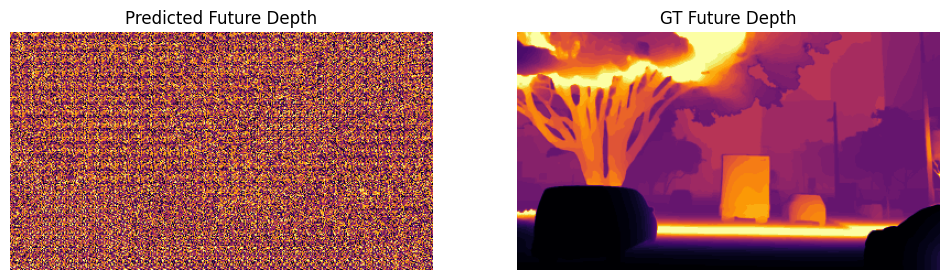

🎉 SANITY CHECK COMPLETE — MODEL BEHAVING NORMALLY


In [6]:
model = FixedFUTURIST(config).cuda()
loader = create_final_futurist_loader_npy(
    shard_pattern="/content/sequence_shards/seq-{00000..00168}.tar",
    batch_size=4,
    num_workers=2
)

sanity_check(model, loader, config)


In [7]:
# ============================================================
# FIXED IMPORTS
# ============================================================

import torch.optim as optim
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ============================================================
# FIXED EVALUATION METRICS (COMPLETE SET)
# ============================================================

def calculate_miou(pred, target, num_classes=19):
    """Calculate mean Intersection over Union - FIXED for 5D inputs"""
    device = pred.device

    # Handle 5D inputs: [B, F, C, H, W] -> [B*F, C, H, W]
    if len(pred.shape) == 5:
        B, F, C, H, W = pred.shape
        pred = pred.reshape(B * F, C, H, W)
        target = target.reshape(B * F, H, W)

    pred_labels = torch.argmax(pred, dim=1)  # [B*F, H, W]

    ious = []
    for class_id in range(num_classes):
        pred_mask = (pred_labels == class_id)
        target_mask = (target == class_id)

        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()

        if union > 0:
            ious.append(intersection / union)
        else:
            ious.append(torch.tensor(0.0, device=device))

    return torch.mean(torch.stack(ious)) if ious else torch.tensor(0.0, device=device)


def calculate_miou_movable_objects(pred, target):
    """Calculate mIoU for movable classes (Cityscapes 11–18) with proper handling."""
    device = pred.device
    movable_classes = [11, 12, 13, 14, 15, 16, 17, 18]

    # Handle 5D inputs: [B, F, C, H, W] -> [B*F, C, H, W]
    if len(pred.shape) == 5:
        B, F, C, H, W = pred.shape
        pred = pred.reshape(B * F, C, H, W)
        target = target.reshape(B * F, H, W)

    pred_labels = torch.argmax(pred, dim=1)

    ious = []
    for class_id in movable_classes:
        pred_mask = (pred_labels == class_id)
        target_mask = (target == class_id)

        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()

        # ✔️ IMPORTANT: include class even if missing
        if union > 0:
            iou = intersection / union
        else:
            iou = torch.tensor(0.0, device=device)

        ious.append(iou)

    return torch.mean(torch.stack(ious))


def calculate_depth_metrics(pred, target, depth_bins=50):
    if len(pred.shape) == 5:
        B, F, C, H, W = pred.shape
        pred = pred.reshape(B * F, C, H, W)
        target = target.reshape(B * F, H, W)

    # Get bin predictions
    pred_bins = torch.argmax(pred, dim=1).float()
    target_bins = target.float()

    # ✅ Mask out invalid bins:
    # - exclude 0 (invalid / infinite depth)
    # - exclude 255 (void)
    # - keep [1, depth_bins-1] inclusive
    valid = (target_bins > 0) & (target_bins < depth_bins) & (target_bins != 255)

    pred_bins  = pred_bins[valid]
    target_bins = target_bins[valid]

    if pred_bins.numel() == 0:
        return torch.tensor(0.0), torch.tensor(0.0)

    # Convert to normalized disparity
    pred_disp = pred_bins / (depth_bins - 1)
    target_disp = target_bins / (depth_bins - 1)

    abs_rel = torch.mean(torch.abs(pred_disp - target_disp) / (target_disp + 1e-6))

    ratio = torch.max(
        pred_disp / (target_disp + 1e-6),
        target_disp / (pred_disp + 1e-6)
    )
    delta1 = torch.mean((ratio < 1.25).float())

    return abs_rel * 100, delta1 * 100

# ============================================================
# FIXED TRAINING FUNCTION
# ============================================================

def train_futurist_model_memory_optimized():
    print("🚨 USING MEMORY-OPTIMIZED TRAINING WITH GRADIENT ACCUMULATION")

    # Setup
    model = FixedFUTURIST(config)
    criterion = FixedFUTURISTLoss(config)
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    # Track metrics
    epoch_losses = []
    epoch_seg_losses = []
    epoch_depth_losses = []

    # Paper metrics tracking
    train_miou_all = []
    train_miou_mo = []
    train_abs_rel = []
    train_delta1 = []

    # Memory optimizations
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    if device == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    # Data loader
    train_loader = create_final_futurist_loader_npy(
        shard_pattern="/content/sequence_shards/seq-{00000..00168}.tar",
        batch_size=8,
        num_workers=2
    )

    # Gradient accumulation
    accumulation_steps = 4

    # Training loop
    model.train()

    for epoch in range(25):
        epoch_start = time.time()
        total_loss = 0
        total_seg_loss = 0
        total_depth_loss = 0
        num_batches = 0

        # Track metrics for this epoch
        epoch_miou_all = 0
        epoch_miou_mo = 0
        epoch_abs_rel = 0
        epoch_delta1 = 0

        optimizer.zero_grad()

        progress_bar = tqdm(train_loader, desc=f'🚀 Epoch {epoch+1}/25')

        for batch_idx, batch in enumerate(progress_bar):
            # Get data
            seg_seq = batch['seg_sequence'].to(device)        # [B,5,1,H,W]
            depth_seq = batch['depth_sequence'].to(device)
            seg_target = batch['seg_target'].to(device)
            depth_target = batch['depth_target'].to(device)

            # Remove the channel dimension explicitly, but ONLY if it's 1:
            seg_seq = seg_seq[:, :, 0]        # [B,5,H,W]
            depth_seq = depth_seq[:, :, 0]
            seg_target = seg_target[:, :, 0]
            depth_target = depth_target[:, :, 0]


            # Forward pass WITH MASKING (for training)
            seg_pred, depth_pred, seg_mask, depth_mask = model(
                seg_seq, depth_seq, apply_masking=True
            )

            # Use correct targets (future frames only in the loss)
            loss, seg_loss, depth_loss = criterion(
                seg_pred, depth_pred,
                seg_target, depth_target,
                seg_mask, depth_mask
            )

            # Scale loss for gradient accumulation
            loss = loss / accumulation_steps
            loss.backward()

            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()

            # ===== METRICS: ONLY ON 5th (FUTURE) FRAME =====
            with torch.no_grad():
                # seg_pred, depth_pred: [B, 1, C, H, W]
                # seg_target, depth_target: [B, 5, H, W] -> slice future only
                seg_gt_future   = seg_target[:, -1:]      # [B, 1, H, W]
                depth_gt_future = depth_target[:, -1:]    # [B, 1, H, W]

                batch_miou_all = calculate_miou(seg_pred, seg_gt_future)
                batch_miou_mo  = calculate_miou_movable_objects(seg_pred, seg_gt_future)
                batch_abs_rel, batch_delta1 = calculate_depth_metrics(depth_pred, depth_gt_future)


            # Accumulate (scale back loss for logging)
            total_loss += loss.item() * accumulation_steps
            total_seg_loss += seg_loss.item()
            total_depth_loss += depth_loss.item()
            epoch_miou_all += batch_miou_all.item()
            epoch_miou_mo += batch_miou_mo.item()
            epoch_abs_rel += batch_abs_rel.item()
            epoch_delta1 += batch_delta1.item()
            num_batches += 1

            # Update progress bar
            memory_allocated = torch.cuda.memory_allocated() / 1024**3 if device == 'cuda' else 0.0
            progress_bar.set_postfix({
                'loss': f'{(loss.item() * accumulation_steps):.4f}',
                'mIoU': f'{batch_miou_all.item():.3f}',
                'δ1': f'{batch_delta1.item():.1f}%',
                'mem': f'{memory_allocated:.1f}GB'
            })

            if batch_idx % 10 == 0 and device == 'cuda':
                torch.cuda.empty_cache()

        # ✅ FIX: Handle remaining gradients without using len(train_loader)
        if num_batches > 0 and num_batches % accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        scheduler.step()

        # Calculate epoch averages
        avg_loss = total_loss / num_batches
        avg_miou_all = epoch_miou_all / num_batches
        avg_miou_mo = epoch_miou_mo / num_batches
        avg_abs_rel = epoch_abs_rel / num_batches
        avg_delta1 = epoch_delta1 / num_batches

        epoch_losses.append(avg_loss)
        train_miou_all.append(avg_miou_all)
        train_miou_mo.append(avg_miou_mo)
        train_abs_rel.append(avg_abs_rel)
        train_delta1.append(avg_delta1)

        print(f'\n🎯 EPOCH {epoch+1} COMPLETE:')
        print(f'   📊 Loss: {avg_loss:.4f} | Seg: {total_seg_loss/num_batches:.4f} | Depth: {total_depth_loss/num_batches:.4f}')
        print(f'   🎨 mIoU: {avg_miou_all:.3f} | MO-mIoU: {avg_miou_mo:.3f}')
        print(f'   📏 Depth: AbsRel: {avg_abs_rel:.2f}% | δ1: {avg_delta1:.1f}%')
        print(f'   🔄 Batches processed: {num_batches}')

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': avg_loss,
                'metrics': {
                    'mIoU_all': avg_miou_all,
                    'mIoU_mo': avg_miou_mo,
                    'AbsRel': avg_abs_rel,
                    'Delta1': avg_delta1
                },
                'config': config
            }
            torch.save(checkpoint, f'/content/futurist_epoch_{epoch+1}.pth')
            print(f'   💾 Checkpoint saved: futurist_epoch_{epoch+1}.pth')

        # Clear memory at end of epoch
        if device == 'cuda':
            torch.cuda.empty_cache()

    # Save final model
    final_checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'final_loss': epoch_losses[-1],
        'final_metrics': {
            'mIoU_all': train_miou_all[-1],
            'mIoU_mo': train_miou_mo[-1],
            'AbsRel': train_abs_rel[-1],
            'Delta1': train_delta1[-1]
        },
        'config': config
    }
    torch.save(final_checkpoint, '/content/futurist_final.pth')
    print('   💾 Final model saved: futurist_final.pth')

    return model, epoch_losses, train_miou_all, train_miou_mo, train_abs_rel, train_delta1

# ============================================================
# START FIXED TRAINING
# ============================================================

print("🔥 STARTING FIXED TRAINING...")

trained_model, losses, miou_all, miou_mo, abs_rel, delta1 = train_futurist_model_memory_optimized()

print("\n🎉 TRAINING COMPLETE!")
print(f"🚀 Final Epoch Loss: {losses[-1]:.4f}")
print(f"🎨 Final mIoU: {miou_all[-1]:.3f} | MO-mIoU: {miou_mo[-1]:.3f}")
print(f"📏 Final Depth: AbsRel: {abs_rel[-1]:.2f}% | δ1: {delta1[-1]:.1f}%")
print("💾 Model saved: /content/futurist_final.pth")

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


🔥 STARTING FIXED TRAINING...
🚨 USING MEMORY-OPTIMIZED TRAINING WITH GRADIENT ACCUMULATION
✅ FIXED FUTURIST Model Created:
   - Parameters: 3,322,290
   - Hidden dim: 192
   - Layers: 4
   - Sequence: 5 frames (4 context + 1 future)
   - Image: 216x384 -> 576 patches
   - Pixel embed dim: 10 (paper: 10)
   - Masking: Future frame 100% masked during training


🚀 Epoch 1/25: 4652it [07:45,  9.04it/s, loss=1.6324, mIoU=0.209, δ1=83.5%, mem=0.3GB]

Sample processing error: 'label04.npy'
Sample processing error: 'label03.npy'
Sample processing error: 'label02.npy'
Sample processing error: 'label01.npy'
Sample processing error: 'label00.npy'


🚀 Epoch 1/25: 5256it [08:43, 10.03it/s, loss=2.4593, mIoU=0.204, δ1=74.9%, mem=0.3GB]


...


🎯 EPOCH 24 COMPLETE:
   📊 Loss: 1.3868 | Seg: 0.3052 | Depth: 1.0816
   🎨 mIoU: 0.285 | MO-mIoU: 0.107
   📏 Depth: AbsRel: 21.45% | δ1: 82.9%
   🔄 Batches processed: 5256


🚀 Epoch 25/25: 4652it [07:44,  9.09it/s, loss=1.0186, mIoU=0.275, δ1=91.0%, mem=0.3GB]

Sample processing error: 'label04.npy'
Sample processing error: 'label03.npy'
Sample processing error: 'label02.npy'
Sample processing error: 'label01.npy'
Sample processing error: 'label00.npy'


🚀 Epoch 25/25: 5256it [08:42, 10.05it/s, loss=1.5997, mIoU=0.263, δ1=83.2%, mem=0.3GB]



🎯 EPOCH 25 COMPLETE:
   📊 Loss: 1.3792 | Seg: 0.3033 | Depth: 1.0758
   🎨 mIoU: 0.286 | MO-mIoU: 0.108
   📏 Depth: AbsRel: 21.20% | δ1: 83.1%
   🔄 Batches processed: 5256
   💾 Final model saved: futurist_final.pth

🎉 TRAINING COMPLETE!
🚀 Final Epoch Loss: 1.3792
🎨 Final mIoU: 0.286 | MO-mIoU: 0.108
📏 Final Depth: AbsRel: 21.20% | δ1: 83.1%
💾 Model saved: /content/futurist_final.pth
